In [26]:
import time
import numpy as np
import matplotlib.pyplot as plt

In [27]:
# Для работы с CUDA используется библиотека CuPy
import cupy as cp

In [28]:
# Тип используемого GPU
!nvidia-smi

Tue Apr  7 19:30:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   75C    P0             34W /   70W |     113MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [29]:
# Тип используемого CPU
!lscpu | grep "Model name"

Model name:                              Intel(R) Xeon(R) CPU @ 2.00GHz


In [30]:
# Вспомогательный метод для заполнения вектора случайными числами

def create_random_vector(length):

    return np.random.rand(length).astype(np.float32)

In [31]:
# Код на C++ для CUDA - ядра

cuda_reduce_src = r'''
extern "C" __global__
void GPU_reduce_sum(const float* input_arr, float* out_sum, int length)
{

    // Нахождение глобального (в блоке) и локального индекса потока
    int global_id = blockIdx.x * blockDim.x + threadIdx.x;
    int local_id = threadIdx.x;

    // Использование shared памяти для последующего выполнения редукции
    __shared__ float smem_cache[256]; // размерность блока

    // Вычисление локальных значений сумм
    float temp_val = 0.0f;
    if (global_id < length)
    {
        temp_val = input_arr[global_id];
    }

    // Запись локального значения суммы в shared память
    smem_cache[local_id] = temp_val;
    __syncthreads(); // Синхронизация потоков

    // Механизм редукции в shared памяти
    for (int stride = blockDim.x / 2; stride > 0; stride /= 2)
    {
        if (local_id < stride)
        {
            smem_cache[local_id] += smem_cache[local_id + stride];
        }
        __syncthreads(); // Синхронизация потоков
    }

    // Запись результата блока в глобальную память
    if (local_id == 0)
    {
        atomicAdd(out_sum, smem_cache[0]); // Atomic - операция для обеспечения потокобезопасности
    }
}
'''
compiled_reduce_kernel = cp.RawKernel(cuda_reduce_src, 'GPU_reduce_sum')

In [34]:
# Код для последовательного нахождения суммы элементов вектора на CPU

def compute_sum_CPU(host_array):

    total = 0.0
    for val in host_array:
        total += val

    return total

In [35]:
# Код для нахождения суммы элементов вектора на GPU

def compute_sum_GPU(host_array):

    arr_len = host_array.size

    # Перенос элементов вектора в память GPU
    GPU_array = cp.asarray(host_array, dtype=cp.float32)
    GPU_out = cp.zeros(1, dtype=cp.float32)

    # Конфигурация сетки блоков (256 потоков на блок)
    threads_per_block = 256
    blocks_per_grid = (arr_len + threads_per_block - 1) // threads_per_block

    # Запуск CUDA ядра
    compiled_reduce_kernel((blocks_per_grid,), (threads_per_block,), (GPU_array, GPU_out, arr_len))

    # Возвращение результата для GPU
    return cp.asnumpy(GPU_out)[0]

In [36]:
# Подсчет времени выполнения сложения на CPU

def measure_CPU_performance(data_array):

    t_start = time.time()
    result = compute_sum_CPU(data_array)
    t_end = time.time()

    return result, (t_end - t_start)

In [37]:
# Подсчет времени выполнения сложения на GPU

def measure_GPU_performance(data_array):

    t_start = time.time()
    result = compute_sum_GPU(data_array)
    cp.cuda.Stream.null.synchronize() # Блокировка до окончания выполнения операций на GPU
    t_end = time.time()

    return result, (t_end - t_start)

In [38]:
# Проверка поэлементного совпадения результирующих сумм  CPU/GPU с заданной точностью

# Поскольку редукция меняет порядок сложения в сравнении с последовательным вычислением суммы (CPU), необходимо
# более щадящее ограничение на эквивалентность итоговых сумм

def validate_correctness(val_CPU, val_GPU, rel_tol=1e-3, abs_tol=1.0):

    return np.isclose(val_CPU, val_GPU, rtol=rel_tol, atol=abs_tol)

In [40]:
# Подсчет времени выполнения сложения и величины ускорения

def orchestrate_benchmarks(sizes_list):

    CPU_durations = []
    GPU_durations = []

    # Задание вектора требуемой размерности
    for size in sizes_list:
        data_arr = create_random_vector(size)

        # Сложение на CPU
        res_CPU, duration_CPU = measure_CPU_performance(data_arr)
        CPU_durations.append(duration_CPU)

        # Сложение на GPU
        res_GPU, duration_GPU = measure_GPU_performance(data_arr)
        GPU_durations.append(duration_GPU)

        # Проверка корректности сложения
        if validate_correctness(res_CPU, res_GPU):
            validation_status = "PASS"
        else:
            validation_status = f"FAIL (CPU: {res_CPU:.2f}, GPU: {res_GPU:.2f})"

        # Нахождение величины ускорения
        speedup = duration_CPU / duration_GPU if duration_GPU > 0 else 0

        print(f"Размерность исходного вектора: {size:,} | "
              f"CPU: {duration_CPU:.4f} сек | "
              f"GPU: {duration_GPU:.4f} сек | "
              f"Ускорение: {speedup:.2f} x | "
              f"Корректность вычисления суммы: {validation_status}")

    return CPU_durations, GPU_durations


In [41]:
# Построение графиков результатов сложения

def visualize_benchmarks(sizes_list, CPU_times, GPU_times):

    acceleration_factors = [h / d if d > 0 else 0 for h, d in zip(CPU_times, GPU_times)]

    fig, (ax_time, ax_speedup) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))

    # График №1 - Значение времени сложения элементов вектора на CPU/GPU в секундах
    ax_time.plot(sizes_list, CPU_times, label="CPU", marker='o', linewidth=2, color='darkred')
    ax_time.plot(sizes_list, GPU_times, label="GPU", marker='s', linewidth=2, color='dodgerblue')

    ax_time.set_xlabel("Размерность вектора N (в долях миллиона)", fontsize=11)
    ax_time.set_ylabel("Время выполнения (Сек)", fontsize=11)

    ax_time.set_title("Сравнение времени вычислений на CPU и GPU", fontsize=14, fontweight='bold')
    ax_time.grid(True, linestyle='--', alpha=0.6)
    ax_time.legend(loc='upper left', fontsize=11)

    # График №2 - Значение ускорения (кратного выигрыша во времени при параллелизации вычислений на GPU)
    ax_speedup.plot(sizes_list, acceleration_factors, label="Ускорение", marker='^', linewidth=2, color='forestgreen')

    ax_speedup.set_xlabel("Размерность вектора N (в долях миллиона)", fontsize=11)
    ax_speedup.set_ylabel("Ускорение (CPU / GPU)", fontsize=11)

    ax_speedup.set_title("Величина ускорения", fontsize=14, fontweight='bold')
    ax_speedup.grid(True, linestyle='--', alpha=0.6)
    ax_speedup.legend(loc='upper left', fontsize=11)

    # Вывод полученных графиков
    plt.tight_layout()
    plt.show()

Старт вычислений для векторов следующих размерностей: [1000, 25000, 50000, 100000, 250000, 500000, 750000, 1000000]

Размерность исходного вектора: 1,000 | CPU: 0.0001 сек | GPU: 0.0460 сек | Ускорение: 0.00 x | Корректность вычисления суммы: PASS
Размерность исходного вектора: 25,000 | CPU: 0.0024 сек | GPU: 0.0003 сек | Ускорение: 7.91 x | Корректность вычисления суммы: PASS
Размерность исходного вектора: 50,000 | CPU: 0.0051 сек | GPU: 0.0002 сек | Ускорение: 21.53 x | Корректность вычисления суммы: PASS
Размерность исходного вектора: 100,000 | CPU: 0.0095 сек | GPU: 0.0002 сек | Ускорение: 40.22 x | Корректность вычисления суммы: PASS
Размерность исходного вектора: 250,000 | CPU: 0.0242 сек | GPU: 0.0004 сек | Ускорение: 57.85 x | Корректность вычисления суммы: PASS
Размерность исходного вектора: 500,000 | CPU: 0.0491 сек | GPU: 0.0007 сек | Ускорение: 68.61 x | Корректность вычисления суммы: PASS
Размерность исходного вектора: 750,000 | CPU: 0.0826 сек | GPU: 0.0013 сек | Ускорени

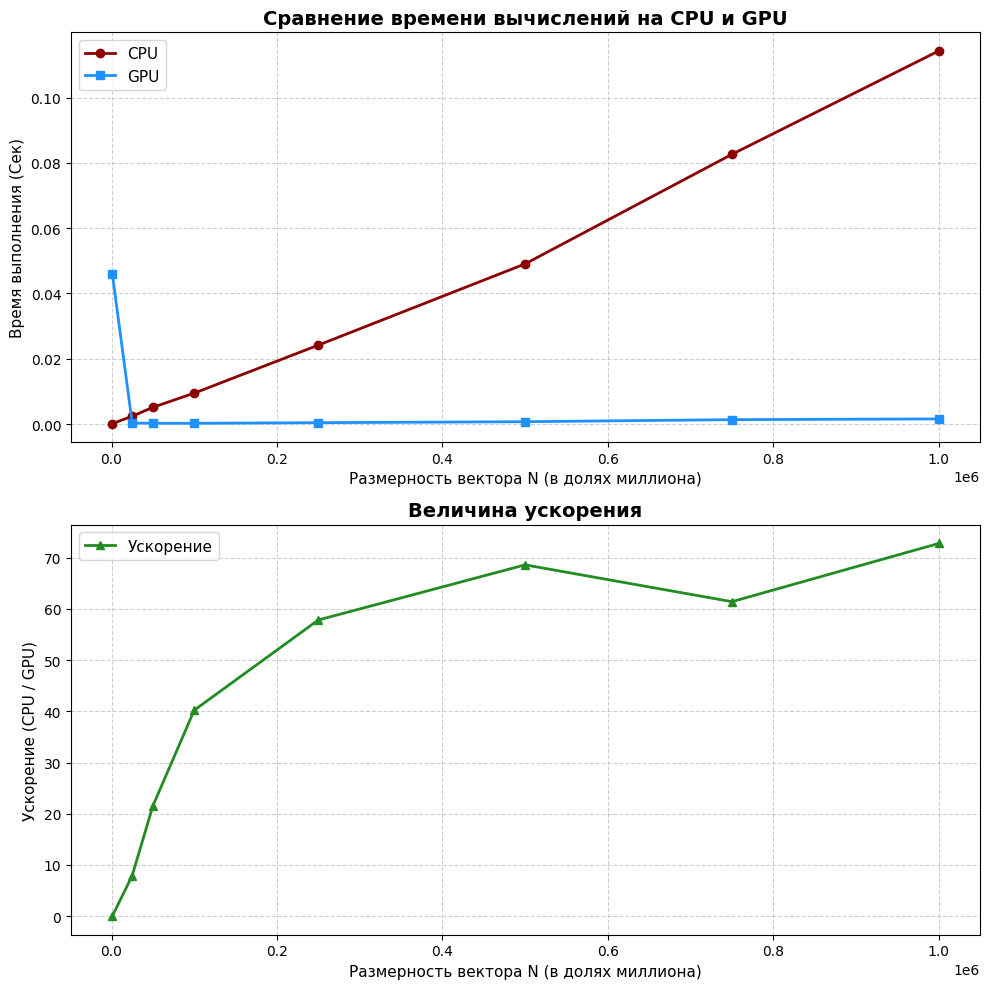

In [42]:
# Задание векторов размерностью: 1000, 25000, 50000, 100000, 250000, 500000, 750000, 1000000

if __name__ == "__main__":

    vector_dimensions = [1000, 25000, 50000, 100000, 250000, 500000, 750000, 1000000]

    print(f"Старт вычислений для векторов следующих размерностей: {vector_dimensions}\n")
    cpu_records, gpu_records = orchestrate_benchmarks(vector_dimensions)

    print("\nВизуализация результатов работы программы")
    visualize_benchmarks(vector_dimensions, cpu_records, gpu_records)